In [1]:
import matplotlib.pyplot as plt
import torch
import os
from pathlib import Path
from importlib import reload
import numpy as np


# Random Experiments

In [3]:
vae_name = "VQ-VAE-256-DR3opt-FT"

from glori.models.load import parse_lightning_ckpt

ckpt_path = parse_lightning_ckpt(ckpt='best', model_name=vae_name)


PosixPath('/hs/fs08/data/group-brueggen/tmartinez/model_results/VQ-VAE-256-DR3opt-FT/lightning/best-train_step=00460500-val_loss=1.56044e-01_bkp.ckpt')

In [18]:
import torch

ckpt = torch.load(ckpt_path, map_location='cpu')
torch.save(
    ckpt,
    ckpt_path.with_name(ckpt_path.stem + "_bkp.ckpt")
)
pprint(list(ckpt.keys()))

['epoch',
 'global_step',
 'pytorch-lightning_version',
 'state_dict',
 'loops',
 'callbacks',
 'optimizer_states',
 'lr_schedulers',
 'hparams_name',
 'hyper_parameters']


In [19]:
from pprint import pprint

ckpt['hyper_parameters']['vq_kwargs'].pop('distance_fn')

pprint(ckpt['hyper_parameters'])

{'attention_head_channels': 32,
 'attention_heads': 2,
 'attention_levels': 0,
 'channel_mults': [1, 2, 4],
 'codebook_start': 0,
 'codebook_weight': 1,
 'disc_iter_start': 10000,
 'disc_loss': 'hinge',
 'disc_norm': 'instance',
 'disc_num_layers': 3,
 'disc_update_rate': 1,
 'disc_weight': 0.1,
 'dropout': 0,
 'dynamic_freezing': False,
 'emb_dim': 3,
 'image_channels': 1,
 'init_channels': 128,
 'lr': 5e-06,
 'lr_disc': 2e-05,
 'n_embed': 2048,
 'norm_groups': 32,
 'num_res_blocks': 2,
 'overfit_batch': False,
 'pixel_loss': 'l1',
 'pixelloss_weight': 1,
 'pretrain_disc': False,
 'scaler': 'LOFAR_scaler_II',
 'train_mode': 'standard',
 'unsc_pixel_weight': 100.0,
 'vq_kwargs': {'affine_lr': 10,
               'beta': 0.9,
               'cb_norm': 'none',
               'kmeans_init': True,
               'norm': 'bn',
               'replace_freq': 20,
               'sync_nu': 0.2},
 'z_channels': 3}


In [20]:
# Override
torch.save(ckpt, ckpt_path)

In [2]:
from models.config import modelConfig

preset_name = "VQ-VAE"
conf = modelConfig.from_preset(preset_name)

In [3]:
import data.sets.datasets as datasets
from data.trf.transforms import WebdatasetTransformCrop
from functools import partial
from plotting.images import plot_image_grid
import data.trf.transforms as T
import utils.paths as paths

num_workers = 16

# Load datasets
dset_kwargs = dict(
    dset=conf.dataset,
    output_tuple=("npy",),
    missing_is_error=conf.get("missing_is_error", True),
    max_beam_arcsec=conf.get("max_beam_arcsec", 6),
    dset_lookup=getattr(
        paths, conf.get("dataset_lookup", "MICROMAP_SUBSETS_HOPPER")
    ),
    scaler=conf.get("scaler"),
)
crop_trf = partial(
    T.WebdatasetTransformCrop,
    crop_size=conf.get("image_size", 256),
)
num_workers = conf.get("num_workers", num_workers)
dl_kwargs = dict(
    batch_size=conf.batch_size,
    num_workers=conf.get("num_workers", num_workers),
    pin_memory=True,
    prefetch_factor=8,
    persistent_workers=True if num_workers > 0 else False,
)
# Train set
train_set = datasets.MicromapDatasetHF(
    **dset_kwargs,
    split="train",
    weights_file=conf.get("weights_file"),
    custom_transform=partial(
        crop_trf,
        random_crop=True,
    ),
)
train_dataloader = train_set.get_dataloader(shuffle=False, **dl_kwargs)


 11:46:26 (MMDsHF) - INFO : Loading arrow dataset from
	/hs/babbage/data/group-brueggen/tmartinez/diffusion/image_data_local/LOFAR/micromaps-arrow/micromaps-DR3-opt-1024px-spacing=1/train.arrow


Loading dataset from disk:   0%|          | 0/436 [00:00<?, ?it/s]

OSError: Expected to be able to read 214267400 bytes for message body, got 166019888

In [17]:
# Scan Arrow shards and report corrupt ones
from pathlib import Path
from datasets import Dataset
from tqdm import tqdm

shard_dir = paths.MICROMAP_SUBSETS_ARROW_BABBAGE[conf.dataset] / "train.arrow"
bad = []

test_list = [paths.MICROMAP_SUBSETS_ARROW_HOPPER[conf.dataset] / "train.arrow" / "data-00097-of-00436.arrow"]

for p in tqdm(sorted(shard_dir.glob("*.arrow"))):
# for p in tqdm(test_list):
    try:
        _ = Dataset.from_file(str(p))
    except Exception as e:
        bad.append((p, str(e)))

print(f"bad shards: {len(bad)}")
for p, e in bad[:20]:
    print(p, "->", e)

100%|██████████| 437/437 [00:03<00:00, 144.48it/s]

bad shards: 0


In [15]:
print(paths.MICROMAP_SUBSETS_ARROW_HOPPER[conf.dataset] / "train.arrow" / "data-00097-of-00436.arrow")

/storage/tmartinez/image_data/LOFAR/micromaps-arrow/micromaps-DR3-opt-1024px-spacing=1/train.arrow/data-00097-of-00436.arrow


torch.Size([10, 1, 256, 256])


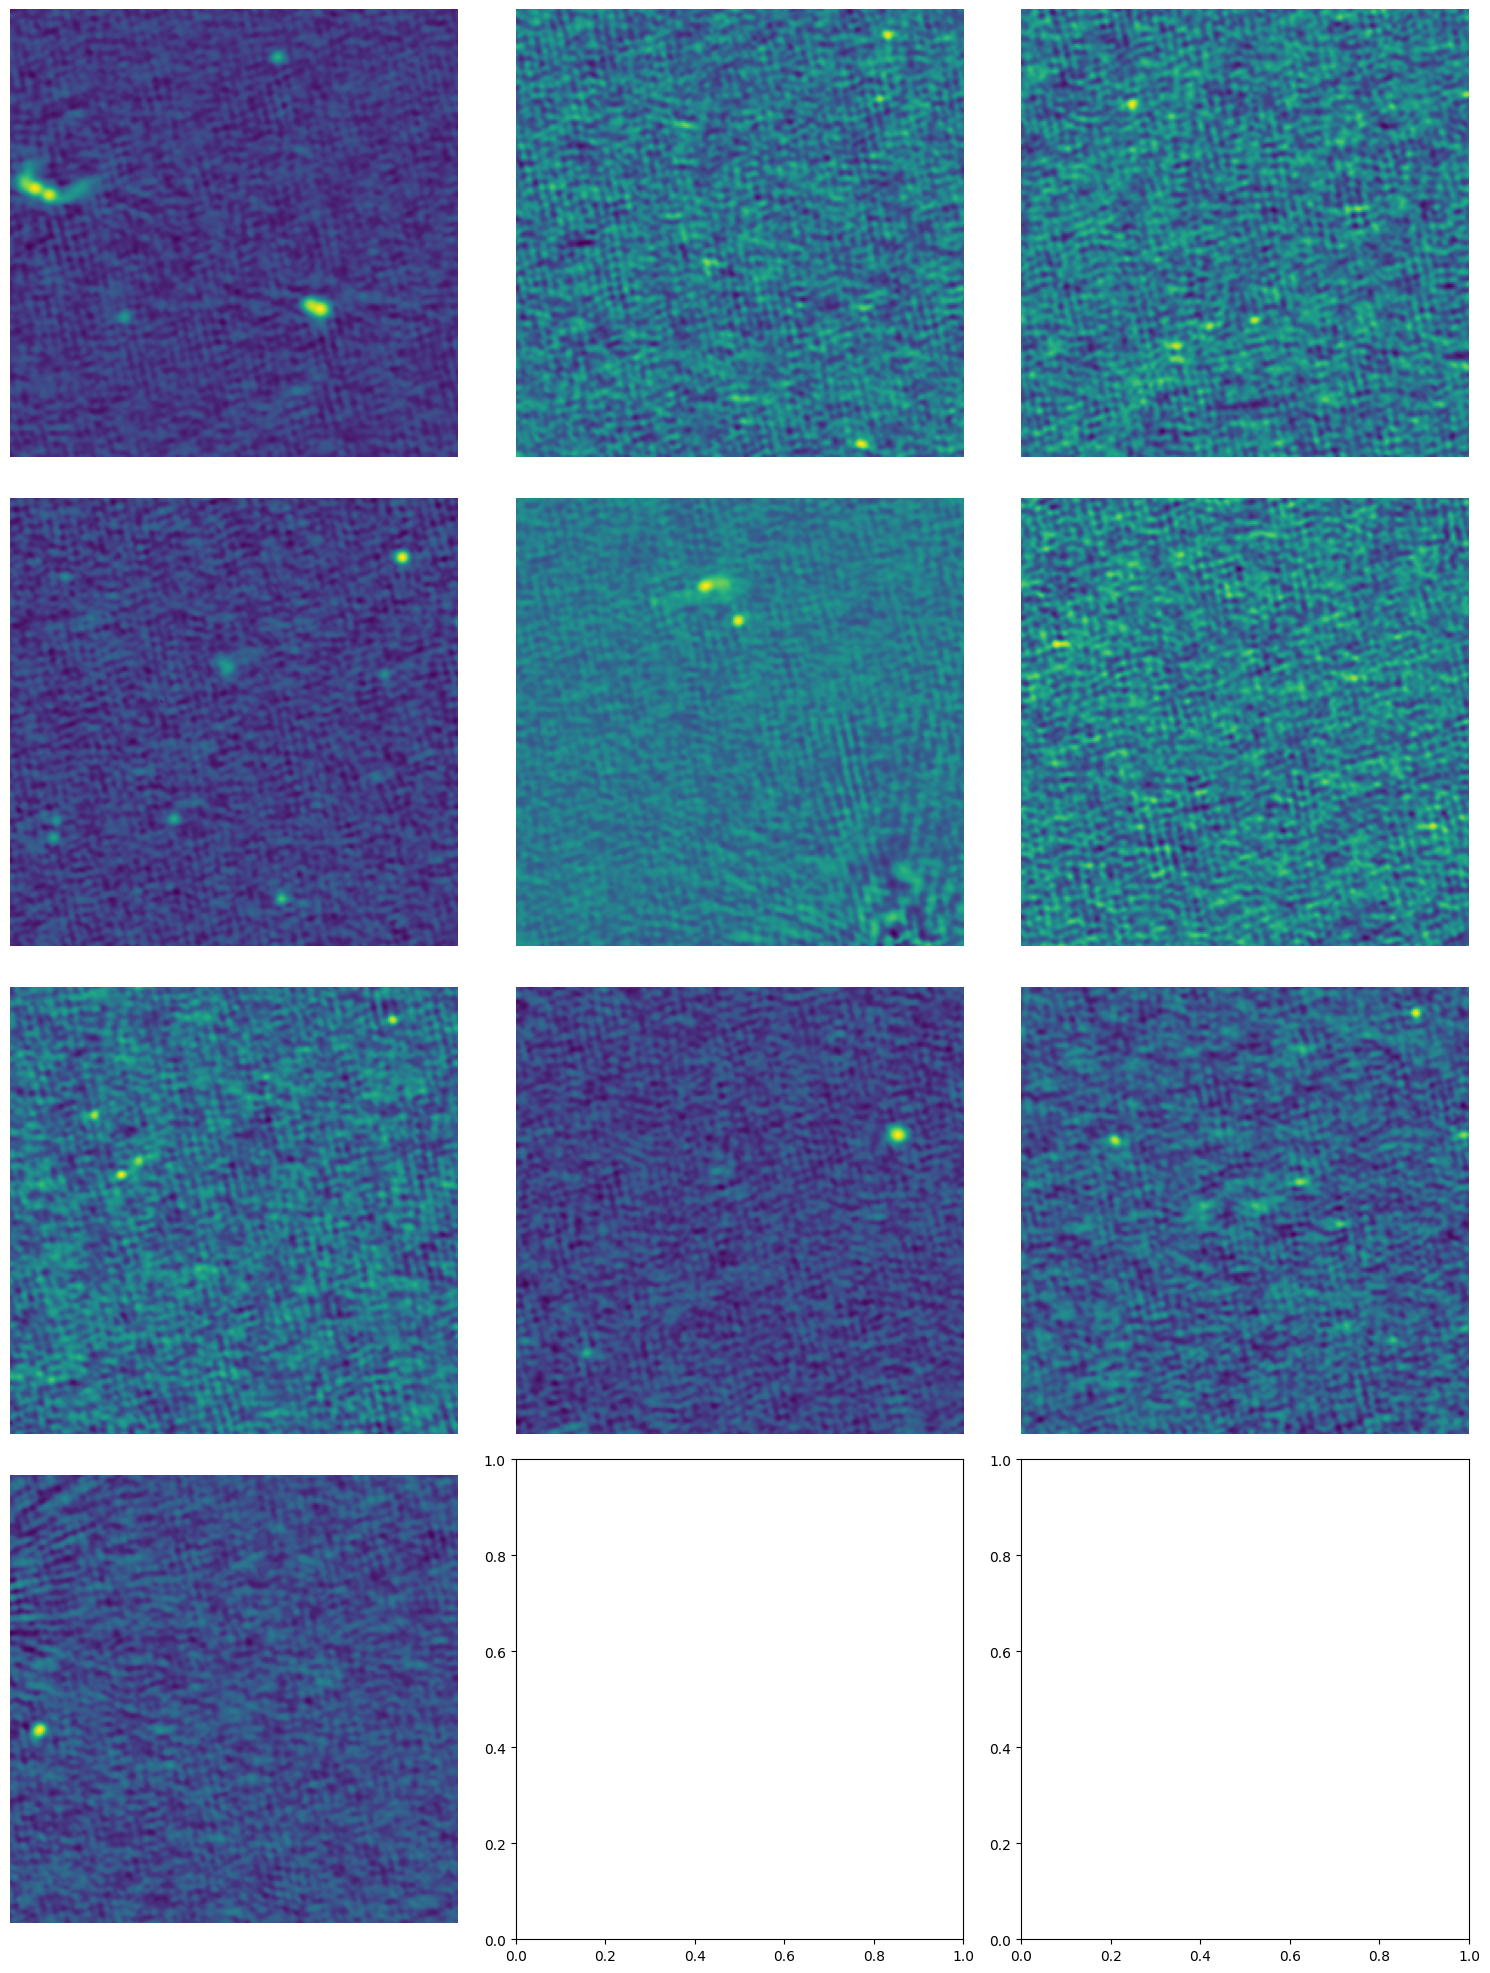

In [4]:
train_dataloader = train_set.get_dataloader(shuffle=False, **dl_kwargs)
imgs, = next(iter(train_dataloader))

print(imgs.shape)

from plotting.images import plot_image_grid

_ = plot_image_grid(imgs)

In [ ]:
from pprint import pprint

pprint(list(sample.keys()))

In [ ]:
from plotting.images import plot_image_grid

plot_image_grid(np.log1p(np.array(sample['context_downscaled_d=4_f=2.npy'])))

In [ ]:
import os
from pathlib import Path
from datasets import config

# 1) Check tmp_path directories (edit out_parent to match your run)
out_parent = Path("/hs/fs08/data/group-brueggen/tmartinez/diffusion/image_data/LOFAR/micromaps-arrow/micromap_encodings-DR3-opt-1024px-spacing=1")  # e.g., the out_parent used in the script
split = 'train'
tmp_path = out_parent / f"{split}-tmp.arrow"
print(split, tmp_path, tmp_path.exists())

# 2) Check datasets cache root
cache_root = Path("/hs/fs08/data/group-brueggen/tmartinez/.cache") / "datasets"
print("Cache root:", cache_root, cache_root.exists())

# List most recent cache files (by mtime)
if cache_root.exists():
    files = sorted(cache_root.rglob("*.arrow"), key=lambda p: p.stat().st_mtime, reverse=True)
    print("Most recent cache files:", files[:10])

In [ ]:
from pathlib import Path
from datasets import Dataset, concatenate_datasets, load_from_disk
from tqdm import tqdm

train_dir = Path("/hs/fs08/data/group-brueggen/tmartinez/diffusion/image_data/LOFAR/micromaps-arrow/micromap_encodings-DR3-opt-1024px-spacing=1/train.arrow")

# 1) Collect cache shards
cache_shards = sorted(train_dir.glob("cache-*.arrow"))
print("cache shards:", len(cache_shards))

# 2) Load each cache shard
cache_dsets = []
for shard in tqdm(cache_shards, desc="Loading cache shards"):
    try:
        cache_dsets.append(Dataset.from_file(str(shard)))
    except Exception as e:
        print(f"Failed to load {shard}: {e}")

print("loaded shards:", len(cache_dsets))

# 3) Concatenate and save recovered dataset
if cache_dsets:
    recovered = concatenate_datasets(cache_dsets)
    out_dir = train_dir.with_name("train_recovered.arrow")
    recovered.save_to_disk(str(out_dir))
    print("saved:", out_dir)

In [ ]:
import time
import statistics as stats
from functools import partial
from collections import defaultdict
import multiprocessing as mp

import torch
from torch.utils.data import DataLoader

import data.sets.datasets as datasets
import data.trf.transforms as transforms
from data.trf.functional import zero_center
import data.trf.post as post
from models.config import modelConfig
from collections import defaultdict

# --------- CONFIG (same as denoiser.py) ----------
preset_name = "LDM-Denoiser-EmbCC-64"
split = "train"
num_batches = 200
device = "cuda:0" if torch.cuda.is_available() else "cpu"

conf = modelConfig.from_preset(preset_name)
# conf.train_config['num_workers'] = 0

conf.train_config["context"] = conf.train_config.get("context", [])
if conf.get("img_context") is not None:
    conf.train_config["context"].append("img_context")
if conf.get("catalog_context") is not None:
    conf.train_config["context"].append("catalog_context")
if (topk := conf.get("catalog_topk")) is not None and conf.get(
    "catalog_context"
) is not None:
    conf.model_config["catalog_context_topk"] = topk
    conf.train_config["catalog_context_topk"] = topk

train_conf = modelConfig(**conf.train_config)

output_tuple = ("npy",)
if conf.get("img_context") is not None:
    output_tuple += (conf.img_context,)
if conf.get("catalog_context") is not None:
    output_tuple += (conf.catalog_context,)

# --------- TRANSFORM PROFILING ----------
_manager = mp.Manager()
transform_times = _manager.dict()


def _record_time(name, dt):
    if name not in transform_times:
        transform_times[name] = _manager.list()
    transform_times[name].append(dt)


def time_fn(name, fn):
    def _wrapped(*args, **kwargs):
        t0 = time.perf_counter()
        out = fn(*args, **kwargs)
        _record_time(name, time.perf_counter() - t0)
        return out

    return _wrapped


# Shared timings for getitem
getitem_times = _manager.list()


ctxt_transform = {}
if hasattr(conf, "ctxt_transform"):
    if hasattr(conf, "ctxt_scalers"):
        scale_fns = {
            k: transforms.make_catalog_context_value_scale(v)
            for k, v in conf.ctxt_scalers.items()
        }
    ctxt_transform = {
        k: time_fn(
            f"ctxt:{k}:{v}",
            getattr(transforms, v)(
                **(
                    (dict(scale_fn=scale_fns[k]))
                    if "scale_fns" in locals() and k in scale_fns
                    else {}
                )
            ),
        )
        for k, v in conf.ctxt_transform.items()
    }

post_transforms = []
if train_conf.get("random_crop") is not None:
    post_transforms.append(
        time_fn(
            "post:random_crop",
            post.make_dependent_random_crop(
                crop_size=train_conf.random_crop,
                f=train_conf.get("crop_fctxt", 1),
                s=train_conf.get("crop_sctxt", 1),
                keys=("npy", *list(ctxt_transform.keys())),
            ),
        )
    )

if train_conf.get("blank_center") is not None:
    post_transforms.append(
        time_fn(
            "post:blank_center",
            post.make_post(
                {
                    k: partial(zero_center, f_center=v)
                    for k, v in train_conf.blank_center.items()
                }
            ),
        )
    )

if train_conf.get("artifact_maker") is not None:
    post_transforms.append(
        time_fn(
            "post:artifact_maker",
            post.make_post(
                {k: post.ctxt_to_artifact for k in train_conf.artifact_maker}
            ),
        )
    )

if (topk := train_conf.get("catalog_context_topk")) is not None:
    key = conf.get("catalog_context", None)
    assert key is not None, "catalog_context_topk set but catalog_context missing."
    if "scale_fns" in locals() and key in scale_fns:
        print(
            f"WARNING: scale_fns used for topk on {key}. "
            f"Check topk_min_val={conf.get('topk_min_val', 0)}."
        )
    post_transforms.append(
        time_fn(
            "post:catalog_topk",
            post.make_ctxt_to_topk(
                key=key,
                k=topk,
                min_val=conf.get("topk_min_val", 0),
                copy=False,
            ),
        )
    )

dset_kwargs = dict(
    output_tuple=output_tuple,
    ctxt_transform=ctxt_transform,
    post_transform=post.compose(*post_transforms),
    missing_is_error=train_conf.get("missing_is_error", True),
    max_beam_arcsec=conf.get("max_beam_arcsec", None),
)

if conf.get("weights_fn") is not None:
    dset_kwargs["weights_fn"] = eval(conf.weights_fn)

num_workers = train_conf.get("num_workers", 16)
batch_size = train_conf.batch_size


# --------- PROFILING WRAPPER ----------
class ProfilingDataset(torch.utils.data.Dataset):
    def __init__(self, base, getitem_times):
        self.base = base
        self.getitem_times = getitem_times

    def __len__(self):
        return len(self.base)

    def __getitem__(self, idx):
        t0 = time.perf_counter()
        item = self.base[idx]
        self.getitem_times.append(time.perf_counter() - t0)
        return item


def summarize(name, values):
    if not values:
        return f"{name}: no samples"
    return (
        f"{name}: n={len(values)} "
        f"avg={stats.mean(values):.4f}s "
        f"p50={stats.median(values):.4f}s "
        f"p90={stats.quantiles(values, n=10)[8]:.4f}s "
        f"max={max(values):.4f}s"
    )


# --------- LOAD & PROFILE ----------
base_set = datasets.MicromapDatasetHF(
    dset=conf.dataset,
    split=split,
    weights_file=conf.get("weights_file"),
    **dset_kwargs,
)
prof_set = ProfilingDataset(base_set, getitem_times)

In [ ]:
from tqdm import trange

loader = DataLoader(
    prof_set,
    batch_size=batch_size,
    # num_workers=num_workers,
    num_workers=32,
    pin_memory=False,
    persistent_workers=True if num_workers > 0 else False,
    prefetch_factor=8,
)

timings = defaultdict(list)
device = torch.device(device)

it = iter(loader)
for i in trange(num_batches):
    t0 = time.perf_counter()
    batch = next(it)
    timings["collate+load"].append(time.perf_counter() - t0)

    t1 = time.perf_counter()
    if device.type == "cuda":
        batch = [
            v.to(device, non_blocking=True) if isinstance(v, torch.Tensor) else v
            for v in batch
        ]
        torch.cuda.synchronize()
    timings["h2d"].append(time.perf_counter() - t1)

print("\n=== Dataloader Profiling Summary ===")
print(f"Config: {preset_name} | split={split}")
print(f"batch_size={batch_size} num_workers={num_workers} pin_memory=True")
print(summarize("getitem", list(getitem_times)))
print(summarize("collate+load", timings["collate+load"]))
print(summarize("h2d", timings["h2d"]))

print("\n=== Transform Timing Summary ===")
for name in sorted(transform_times.keys()):
    print(summarize(name, list(transform_times[name])))

In [ ]:
print("\n=== Dataloader Profiling Summary ===")
print(f"Config: {preset_name} | split={split}")
print(f"batch_size={batch_size} num_workers={num_workers} pin_memory=True")
print(summarize("getitem", list(getitem_times)))
print(summarize("collate+load", timings["collate+load"]))
print(summarize("h2d", timings["h2d"]))

print("\n=== Transform Timing Summary ===")
for name in sorted(transform_times.keys()):
    print(summarize(name, list(transform_times[name])))

In [ ]:
# Load fits file
from data.utils import load_fits_catalog

cat_path = Path(
    "/hs/fs08/data/group-brueggen/tmartinez/diffusion/image_data/LOFAR/LoTSS_DR3_v0.5.srl.fits"
)

cat = load_fits_catalog(cat_path, select_cols=None)

In [ ]:
cat.to_parquet(str(cat_path.with_suffix(".parquet")))

In [ ]:
ckpt_file = Path(
    "/hs/fs08/data/group-brueggen/tmartinez/diffusion/model_results/LDM-Denoiser-WnetCC-II-FT/lightning/best-train_step=00634999-val_loss=1.23155e+00.ckpt"
)
from models.diffusion.denoiser import Denoiser

ckpt = torch.load(ckpt_file, map_location="cpu")

denoiser = Denoiser.load_from_checkpoint(ckpt_file, strict=False)

In [ ]:
denoiser.load_state_dict(ckpt["state_dict"], strict=False)

In [ ]:
ckpt.keys()

In [ ]:
keys_to_remove = [
    "model.model.catalog_emb.1.1.weight",
    "model.model.catalog_emb.1.1.bias",
]

# Remove unwanted keys
for key in keys_to_remove:
    if key in ckpt["state_dict"]:
        del ckpt["state_dict"][key]

In [ ]:
# Save the modified checkpoint
torch.save(ckpt, ckpt_file.with_name("modified_" + ckpt_file.name))

In [ ]:
import utils.paths as paths

all_files = sorted(list(paths.MOSAIC_DIR_DR3.glob("*/*.fits")))
all_names = [f.parent.name for f in all_files]

In [ ]:
len(all_files)

In [ ]:
from data.utils import load_fits_image

img, _ = load_fits_image(all_files[0])

In [ ]:
img.shape, f"{(s := (~np.isnan(img)).sum()):_}", np.sqrt(s), f"{4096*2160:_}"

In [ ]:
def printnum(n):
    print(f"{n:_}")


printnum(np.pi * (9802 / 2) ** 2)

In [ ]:
import matplotlib.pyplot as plt

plt.imshow(np.log1p(img))

In [ ]:
75500000 * 2911 / 8_847_360

In [ ]:
import train.utils as tutils

reload(tutils)
from plotting.images import plot_image_grid

mask, ext_mask = tutils.weighted_random_quadrant_mask(
    (16, 3, 128, 128),
    weights=[0, 0, 0, 1],
    make_ext_ctxt_mask=True,
    ext_ctxt_p=[0.9, 0.15, 0.15],
    mask_coverage=0.2,
)

# plot_grid = [m for mm in zip(mask, ext_mask) for m in mm]
plot_grid = mask

_ = plot_image_grid(plot_grid, n_rows=4, vmin=0, vmax=1)

In [ ]:
import utils.paths as paths
from data.obs.micromaps.utils import (
    context_map_by_wcs,
    get_model_image,
    reduce_context_map,
)

cutout_size_px = 2048  # Size of the cutout in pixels
ctxt_type = "cat"  # 'cat' or 'model'

mosaic = -1
mosaic_list = sorted([p.name for p in paths.MOSAIC_DIR_DR3.glob("*") if p.is_dir()])
match mosaic:
    case int():
        mosaic = mosaic_list[mosaic]
    case str():
        if mosaic not in mosaic_list:
            raise ValueError(f"Mosaic {mosaic} not found in available mosaics.")
    case _:
        raise ValueError(f"Invalid mosaic type: {type(mosaic)}")

print("Loading mosaic...")
img, wcs = load_mosaic(mosaic)


# Get the central cutout from the image
def get_slice(img, cutout_size_px):
    cby2, cpx = cutout_size_px // 2, img.shape[-1] // 2
    sl = slice(cpx - cby2, cpx + cby2)
    return sl


sl = get_slice(img, cutout_size_px)
img_cut, wcs_cut = img[sl, sl], wcs[sl, sl]


print("Generating context map...")
ctxt, _ = context_map_by_wcs(
    wcs_cut,
    cat,
    scale_output=False,
)
ctxt_red = reduce_context_map(
    ctxt,
    scale_output=False,
    input_scaled=False,
)

In [ ]:
import plotting.images as imgplt

imgplt.plot_image_grid(
    ctxt,
)

In [ ]:
import matplotlib.pyplot as plt

plt.hist(ctxt_red[2].flatten(), bins=100, log=True)

# Convert catalogs to parquet

In [ ]:
import pandas as pd
from pathlib import Path
from astropy.table import Table


def convert_to_parquet(file):
    if isinstance(file, str):
        file = Path(file)
    assert isinstance(file, Path), f"File must be a Path or str, got {type(file)}"
    print(f"Reading file: {file.name}...")
    match file.suffix:
        case ".csv":
            df = pd.read_csv(file)
        case ".fits":
            table = Table.read(file)
            df = table.to_pandas()
        case _:
            raise ValueError(f"Unsupported file format: {file.suffix}")

    # Format all columns that are obj to utf-8
    for col in df.columns:
        if df[col].dtype == "object":
            df[col] = df[col].str.decode("utf-8")

    out_file = file.with_suffix(".parquet")
    print(f"Writing to parquet: {out_file.name}...")
    df.to_parquet(out_file)
    return out_file

In [ ]:
import utils.paths as paths

convert_to_parquet(paths.LOTSS_DR3_CAT)

# New LoTSS Catalogs

In [ ]:
import wget

link = "https://lofar-surveys.org/public/DR2/AGN_selection/classified-v1.0.fits"
out = paths.LOFAR_DATA_PARENT / "classified-v1.0.fits"

# Generate terminal command
cmd = f"wget {link} -O {out}"
print(cmd)

In [ ]:
import pandas as pd
from astropy.table import Table
import utils.paths as paths

# Read the file
table = Table.read(str(paths.LOFAR_DATA_PARENT / "classified-v1.0.fits"), format="fits")
names = [name for name in table.colnames if len(table[name].shape) <= 1]
cat = table[names].to_pandas()

In [ ]:
import h5py
import pandas as pd

cut_file = paths.CUTOUTS_DIR / "cutouts_200p_optC.hdf5"
cut_cat = pd.read_hdf(cut_file, key="catalog")

# Remove problem cutouts
cut_cat = cut_cat[cut_cat["Problem_cutout"] == 0]

In [ ]:
A = set(cut_cat.Source_Name.values)
B = set(cat.Source_Name.str.decode("utf-8").values)
A_not_B = A - B
B_not_A = B - A
A_and_B = A & B

print(f"Cutouts: {len(A)}, Classified: {len(B)}")
print(f"Cutouts not in Classified: {len(A_not_B)}")
print(f"Classified not in Cutouts: {len(B_not_A)}")
print(f"Intersection: {len(A_and_B)}")

In [ ]:
# Flag all source names that are in both catalogs
import numpy as np

# Create a boolean flag for the intersection
flg = cat.Source_Name.str.decode("utf-8").isin(A_and_B)
flg_cut = cut_cat.Source_Name.isin(A_and_B)

sub_cat = cat[flg]
sub_cut_cat = cut_cat[flg_cut]

In [ ]:
# Load the cutout images, but only the flagged ones
# This takes 8-10 minutes to load into memory.
with h5py.File(cut_file, "r") as f:
    cutouts = np.array(f["cutouts"])

sub_cutouts = cutouts[flg_cut]

In [ ]:
sub_cutouts.shape

In [ ]:
from plotting.image_plots import metric_peek

SNR = sub_cut_cat["Total_flux"] / sub_cut_cat["E_Total_flux"]

In [ ]:
metric_peek(
    metric=SNR.values,
    edges=np.linspace(0, 100, 11),
    images=sub_cutouts,
    metric_name="SNR",
    n_examples=20,
)

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(10, 5))

flg = sub_cut_cat.LAS.values > 80 * 1.5
ax.hist(
    sub_cut_cat[flg].LAS.values,
    bins=np.linspace(80, 400),
    histtype="step",
    label="SNR",
    cumulative=False,
    density=False,
)
ax.set_yscale("log")
ax.axvline(256 * 1.5, color="r", linestyle="--", label="256 px")

ax.grid(alpha=0.3)
fig.show()

In [ ]:
256 * 1.5

In [ ]:
(sub_cut_cat.LAS.values > 256 * 1.5).sum()

In [ ]:
sub_cat.Source_Name.str.decode("utf-8").is_monotonic_increasing

In [ ]:
sub_cat.Source_Name

In [ ]:
# Load corresponding cutouts
from data.datasets import CutoutsDataset

cut_file = paths.CUTOUTS_DIR / "cutouts_200p_optC.hdf5"
dset = CutoutsDataset(cut_file, img_size=200)

# Image Autocorrelations

In [ ]:
import utils.paths as paths
import h5py
import numpy as np
from data.datasets import LOFARPrototypesDataset, SamplesDataset

# Load training images
train_dset = LOFARPrototypesDataset("prototypes", img_size=80)
imgs = train_dset.data.numpy().squeeze() * train_dset.masks.numpy().squeeze()

In [ ]:
from data.segment import get_sample_mask
from data.transforms import max_scale_batch
from tqdm import tqdm

# Load samples
samples_dset = SamplesDataset(
    "Prototypes_Model_SizeCond", key="samples_Size-Conditioned"
)
samples = max_scale_batch(samples_dset.data.numpy().squeeze())
sample_masks = np.array(
    [
        get_sample_mask(
            img,
            dilate=0,
        )
        for img in tqdm(samples, desc=f"{'Sample source masks':<30}")
    ]
).astype(bool)
samples_masked = samples * sample_masks

In [ ]:
from scipy.stats import binned_statistic
from scipy.signal import correlate2d
import torch
import torch.nn.functional as F


# Get auto-correlation via fft
def autocorr2d_fft(image):
    """
    Compute the 2D autocorrelation of an image.
    """
    # Compute the 2D Fourier transform
    f_transform = np.fft.fft2(image)
    # Compute the power spectrum
    power_spectrum = np.abs(f_transform) ** 2
    # Compute the inverse Fourier transform
    autocorr = np.real(np.fft.ifft2(power_spectrum)) / np.prod(image.shape[-2:])
    return autocorr


def batch_autocorrelation_torch(images):
    images = torch.tensor(images).float()
    N, H, W = images.shape

    # Flip each image as a kernel (for cross-correlation = autocorrelation)
    flipped = torch.flip(images, dims=[1, 2])

    # Expand dims to treat each image as its own "channel"
    input_batch = images.unsqueeze(0)  # Shape (1, N, H, W)
    kernel_batch = flipped.unsqueeze(1)  # Shape (N, 1, H, W)

    # Pad to get full (non-cropped) convolution
    pad = (W - 1,) * 2 + (H - 1,) * 2
    padded_input = F.pad(input_batch, pad, mode="constant", value=0)

    # Use grouped convolution to apply each kernel to its own input
    output = F.conv2d(padded_input, kernel_batch, groups=N) / torch.prod(
        images.shape[-2:]
    )
    return output.squeeze().numpy()  # Shape: (N, 2H-1, 2W-1)


def radii(data):
    y, x = np.indices(data.shape[-2:])
    r = np.sqrt(x**2 + y**2)
    r = np.stack([r] * data.shape[0], axis=0)
    return r


def radial_average(data, nbins=100, centered=True):
    y, x = np.indices(data.shape[-2:])
    if centered:
        y -= data.shape[-2] // 2
        x -= data.shape[-1] // 2
    r = np.sqrt(x**2 + y**2)
    r = np.stack([r] * data.shape[0], axis=0)

    r_bins = np.linspace(0, np.ceil(r.max()), nbins + 1)
    mean = binned_statistic(r.ravel(), data.ravel(), bins=r_bins, statistic="mean")[0]
    std = binned_statistic(r.ravel(), data.ravel(), bins=r_bins, statistic="std")[0]
    counts = binned_statistic(r.ravel(), data.ravel(), bins=r_bins, statistic="count")[
        0
    ]

    return mean, std, r_bins, counts

In [ ]:
import matplotlib.pyplot as plt

for img in imgs[:10]:
    autocorr = autocorr2d(img)

    # Plot
    fig, axs = plt.subplots(1, 2, figsize=(6, 3), constrained_layout=True)
    axs[0].imshow(img)
    axs[1].imshow(autocorr)
    for ax in axs:
        ax.axis("off")
    fig.show()

In [ ]:
print("Calculating images...")
autocorr = batch_autocorrelation_torch(imgs)
mean, std, bins, counts = radial_average(autocorr, nbins=100)

print("Calculating samples...")
autocorr_s = batch_autocorrelation_torch(samples)
mean_s, std_s, bins_s, counts_s = radial_average(autocorr_s, nbins=100)

print("Calculating samples masked...")
autocorr_sm = batch_autocorrelation_torch(samples_masked)
mean_sm, std_sm, bins_sm, counts_sm = radial_average(autocorr_sm, nbins=100)

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6), constrained_layout=True)

# Plot for training data
ax.stairs(mean, bins, label="Training Data", color="b", alpha=0.5)
yerr = std / np.sqrt(counts)
ax.errorbar(
    (bins[:-1] + bins[1:]) / 2,
    mean,
    yerr=yerr,
    fmt="",
    ls="",
    color="b",
)

"""
# Plot for samples
ax.stairs(mean_s, bins_s, label="Samples", color="r", alpha=0.5)
yerr_s = std_s / np.sqrt(counts_s)
ax.errorbar(
    (bins_s[:-1] + bins_s[1:]) / 2,
    mean_s,
    yerr=yerr_s,
    fmt="",
    ls="",
)
"""


# Plot for masked samples
ax.stairs(mean_sm, bins_sm, label="Masked Samples", color="g", alpha=0.5)
yerr_sm = std_sm / np.sqrt(counts_sm)
ax.errorbar(
    (bins_sm[:-1] + bins_sm[1:]) / 2,
    mean_sm,
    yerr=yerr_sm,
    fmt="",
    ls="",
    color="g",
)

ax.legend()
ax.set_xlabel("Radius (px)")
ax.set_ylabel("Autocorrelation")

ax.set_yscale("log")
# ax.set_ylim(bottom=1e-3)
ax.grid(alpha=0.3)

fig.show()

In [ ]:
from matplotlib.colors import LogNorm

fig, axs = plt.subplots(1, 2, figsize=(6, 3), constrained_layout=True)
axs[0].imshow(imgs.mean(axis=0), norm=LogNorm())
axs[1].imshow(autocorr.mean(axis=0), norm=LogNorm())
for ax in axs:
    ax.axis("off")

fig.show()

# LoTSS Maps Pixel Stats

In [ ]:
import utils.paths as paths
from maps.map_utils import get_map_image
import numpy as np


def get_pixels_sample(pointing, n_px=1000):
    p_file = paths.MOSAIC_DIR_DR3 / pointing / "mosaic-blanked.fits"
    map_arr = get_map_image(p_file, get_wcs=False).ravel()
    map_arr = map_arr[~np.isnan(map_arr)]
    random_pxs = np.random.choice(map_arr, n_px)
    max_val = np.max(map_arr)
    min_val = np.min(map_arr)
    return random_pxs, max_val, min_val


pointings = [p.name for p in paths.MOSAIC_DIR_DR3.iterdir()]

In [ ]:
len(pointings)

In [ ]:
from tqdm import tqdm

pxs = np.empty((len(pointings), 1000))
max_vals = np.empty(len(pointings))
min_vals = np.empty(len(pointings))

for i, pointing in tqdm(enumerate(pointings), total=len(pointings)):
    _, mx, mn = get_pixels_sample(pointing, n_px=1)
    max_vals[i] = mx
    min_vals[i] = mn

In [ ]:
# Parallelize the above code with progress bar using process pool executor
from concurrent.futures import ProcessPoolExecutor, as_completed
from tqdm import tqdm

px_per_map = 10_000
pxs = np.empty((len(pointings), px_per_map))
max_vals = np.empty(len(pointings))
min_vals = np.empty(len(pointings))

with ProcessPoolExecutor(max_workers=96) as executor:

    futures = [
        executor.submit(get_pixels_sample, pointing, px_per_map)
        for pointing in pointings
    ]

    with tqdm(total=len(pointings), desc="Processing...") as pbar:
        for i, future in enumerate(as_completed(futures)):
            pxs[i], max_vals[i], min_vals[i] = future.result()
            pbar.update(1)

In [ ]:
# repair file that i just broke
from data.lofar_scaler import LOFARScaler

lscaler2 = LOFARScaler.load("LOFAR_scaler")

pxs = lscaler2.px_sample.copy()

In [ ]:
# Save to file
import h5py

if True:
    with h5py.File(paths.LOFAR_DATA_PARENT / "random_pixels.h5", "w") as f:
        f.create_dataset("pixels", data=pxs)
        f.create_dataset("max_vals", data=max_vals)
        f.create_dataset("min_vals", data=min_vals)

In [ ]:
# Read from file
import h5py

with h5py.File(paths.LOFAR_DATA_PARENT / "random_pixels.h5", "r") as f:
    pxs = np.array(f["pixels"])
    max_vals = np.array(f["max_vals"])

In [ ]:
# Max value distribution
import matplotlib.pyplot as plt
import plotting.plot_utils as pu

reload(pu)
from plotting.plot_utils import add_distribution_plot, auto_log_bins

fig, ax = plt.subplots(1, 1, figsize=(8, 6))

bins = auto_log_bins(max_vals)
cts, bins = np.histogram(max_vals, bins=bins)
add_distribution_plot(cts, bins, ax, auto_xlim=False)

ax.grid(alpha=0.5)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Max Pixel Value")
ax.set_ylabel("Normalized Counts")

fig.show()

In [ ]:
max_vals.max()

In [ ]:
import matplotlib.pyplot as plt
from plotting.plot_utils import add_distribution_plot, auto_log_bins

fig, axs = plt.subplots(1, 2, figsize=(10, 6), sharey=True, constrained_layout=True)

pxs_pos = pxs[pxs > 0].ravel()
pxs_neg = pxs[pxs < 0].ravel()

ax = axs[1]
bins = auto_log_bins(pxs_pos)
cts, bins = np.histogram(pxs_pos, bins=bins)
add_distribution_plot(
    cts, bins, ax, label="Pixels > 0", normalize=False, auto_xlim=False
)
ax.set_xscale("log")

ax = axs[0]
# bins = auto_log_bins(-pxs_neg)
cts, bins = np.histogram(-pxs_neg, bins=bins)
add_distribution_plot(
    cts, bins, ax, label="Pixels < 0", normalize=False, auto_xlim=False
)
ax.set_xscale("log")
ax.invert_xaxis()
ax.set_ylabel("Counts")


for ax in axs:
    ax.grid(alpha=0.3)
    # ax.set_xscale("log")
    # ax.set_yscale("log")
    ax.set_xlabel("Pixel Value")
    ax.legend()

fig.show()

In [ ]:
# Max value distribution
import data.lofar_scaler

reload(data.lofar_scaler)
from data.lofar_scaler import LOFARScaler
import matplotlib.pyplot as plt
from plotting.plot_utils import add_distribution_plot, auto_log_bins

lscaler = LOFARScaler(pxs, thr=1e-4, slope=2e3)

# Plot data distribution
fig, ax = plt.subplots(1, 1, figsize=(8, 6), constrained_layout=True)

bins = 250
cts, bins = np.histogram(lscaler.sym_log_scale(pxs.copy()), bins=bins, density=True)
add_distribution_plot(
    cts,
    bins,
    ax,
    label="Scaled Pixels",
    normalize=False,
    auto_xlim=False,
    errorbar=False,
)

# Plot scaled gaussian distribution
from scipy.stats import norm

bin_width = bins[1] - bins[0]
bin_centers = (bins[1:] + bins[:-1]) / 2
x = np.linspace(-5, 5, 250)
gaus = norm.pdf(x)  #  * cts.sum() * bin_width
ax.plot(x, gaus, alpha=0.1)

ax.set_ylabel("Norm. Counts")
ax.grid(alpha=0.3)
# ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Pixel Value")
ax.legend()
fig.show()

In [ ]:
lscaler.scale(pxs.copy()).mean(), lscaler.scale(pxs.copy()).std()

In [ ]:
lscaler.save("LOFAR_scaler_II")

In [ ]:
import data.lofar_scaler

reload(data.lofar_scaler)
from data.lofar_scaler import LOFARScaler

lscaler2 = LOFARScaler.load("LOFAR_scaler_II")

In [ ]:
pxs2 = lscaler2.inverse_scale(lscaler2.scale(pxs.copy()))

In [ ]:
(pxs - pxs2).max(), (pxs - pxs2).min()

In [ ]:
# Max value distribution
import matplotlib.pyplot as plt
from plotting.plot_utils import add_distribution_plot, auto_log_bins

fig, axs = plt.subplots(1, 2, figsize=(10, 6), sharey=True, constrained_layout=True)

pxs_pos = pxs[pxs > 0].ravel()
pxs_neg = pxs[pxs < 0].ravel()


ax = axs[0]
bins = auto_log_bins(-pxs_neg)
cts, bins = np.histogram(-pxs_neg, bins=bins)
add_distribution_plot(
    cts, bins, ax, label="Pixels < 0", normalize=False, auto_xlim=False
)
ax.set_xscale("log")
ax.invert_xaxis()
ax.set_ylabel("Counts")

ax = axs[1]
bins = auto_log_bins(pxs_pos)
cts, bins = np.histogram(pxs_pos, bins=bins)
add_distribution_plot(
    cts, bins, ax, label="Pixels > 0", normalize=False, auto_xlim=False
)
ax.set_xscale("log")


pxs2_pos = pxs2[pxs2 > 0].ravel()
pxs2_neg = pxs2[pxs2 < 0].ravel()

ax = axs[0]
bins = auto_log_bins(-pxs2_neg)
cts, bins = np.histogram(-pxs2_neg, bins=bins)
add_distribution_plot(
    cts,
    bins,
    ax,
    label="Pixels < 0 (II)",
    normalize=False,
    auto_xlim=False,
    color="orange",
)
ax.set_xscale("log")
# ax.invert_xaxis()
ax.set_ylabel("Counts")

ax = axs[1]
bins = auto_log_bins(pxs2_pos)
cts, bins = np.histogram(pxs2_pos, bins=bins)
add_distribution_plot(
    cts,
    bins,
    ax,
    label="Pixels > 0 (II)",
    normalize=False,
    auto_xlim=False,
    color="orange",
)
ax.set_xscale("log")


for ax in axs:
    ax.grid(alpha=0.3)
    # ax.set_xscale("log")
    # ax.set_yscale("log")
    ax.set_xlabel("Pixel Value")
    ax.legend()

fig.show()

In [ ]:
scaled_data = lscaler.sym_log_scale(pxs.copy())

# Verify the results
print("Variance of scaled data:", np.var(scaled_data))
print("Standard deviation of scaled data:", np.std(scaled_data))
print("Mean of scaled data:", np.mean(scaled_data))
print("RMS of scaled data:", np.sqrt(np.mean(scaled_data**2)))
print("Extreme values of scaled data:", scaled_data.min(), scaled_data.max())

In [ ]:
# Visualize what the normalization does
lim = 10
x = np.linspace(-lim, lim, 1000)
y = lscaler.scale(x.copy())

fig, ax = plt.subplots(1, 1, figsize=(8, 6), constrained_layout=True)

ax.plot(x, y)
# ax.plot(-x, -y)

ax.grid(alpha=0.3)
ax.set_xlabel("Pixel Value")
ax.set_ylabel("Scaled Pixel Value")

fig.show()

In [ ]:
# Plot random pointing with said scaling
import plotting.map_plots

reload(plotting.map_plots)
from plotting.map_plots import plot_sky_map, double_map_plot
from matplotlib.colors import SymLogNorm, Normalize

pointing = np.random.choice(pointings)
print(pointing)
image, wcs = get_image(
    paths.MOSAIC_DIR / pointing / "mosaic-blanked.fits", get_wcs=True
)

image_sc = image.copy()
image_sc[(na_flag)] = lscaler.scale(image[na_flag := ~np.isnan(image_sc)])

clip_quantile = 0.999
vmin = np.quantile(image[image < 0], clip_quantile)
vmax = np.quantile(image[image > 0], clip_quantile)
norm_img = SymLogNorm(linthresh=0.2, vmin=vmin, vmax=vmax)

amax_sc = np.nanmax(np.abs(image_sc))
norm_sc = Normalize(vmin=-amax_sc, vmax=amax_sc)

double_map_plot(
    image,
    image_sc,
    wcs=wcs,
    norm_quantile=None,
    norm=(norm_img, norm_sc),
    kw_map2={"cmap": "seismic"},
)

In [ ]:
plot_sky_map(image, wcs=wcs, norm=norm_img)

In [ ]:
import numpy as np
import jax
import jax.numpy as jnp
from jax import grad, jit


# Optimize for unit variance
def scaler_fn(x, a, s):
    return a * jnp.log(1e4 * s / a * x + 1)


def d_scaler_fn(x, a, s):
    return a * 1e4 * s / (1e4 * s * x + a)


def sym_log_scale(x, a_pos, a_neg, s):
    return jnp.where(x >= 0, scaler_fn(x, a_pos, s), -scaler_fn(-x, a_neg, s))


# Derivative
def d_sym_log_scale(x, a_pos, a_neg, s):
    return jnp.where(x >= 0, d_scaler_fn(x, a_pos, s), -d_scaler_fn(-x, a_neg, s))


# Negative log likelihood
# Log-likelihood function
def nll(params, x):
    y = sym_log_scale(x, *params)
    dy = d_sym_log_scale(x, *params)
    mu = y.mean()

    # Gaussian log-likelihood
    log_p_y = -((y - mu) ** 2) / 2

    # Jacobian term (log |df/dx|)
    log_jacobian = jnp.log(jnp.abs(dy))

    # Negative log-likelihood to minimize
    return -jnp.sum(log_p_y + log_jacobian)


# JIT-compile nll function and its gradient for speed
jit_nll = jit(nll)
jit_grad_nll = jit(grad(nll))

In [ ]:
# Do optimization:
from scipy.optimize import minimize

data = pxs.copy().ravel()
data_jax = jnp.array(data)


# Wrapper function
def objective(params):
    return np.array(jit_nll(params, data_jax), dtype=float)


def objective_grad(params):
    return np.array(jit_grad_nll(params, data_jax), dtype=float)


# Set initial values
a_pos = 1 / np.std(np.log(data[data > 0])) / 0.374
a_neg = 1 / np.std(np.log(-data[data < 0])) / 0.374
slope = 0.5 / 0.374

initial_guess = [a_pos, a_neg, slope]
print("Initial guess:", initial_guess)


def callback(params):
    print("Current parameters:", params)
    print("Current objective value:", objective(params))


print("Minimizing...")
result = minimize(
    objective,
    initial_guess,
    jac=objective_grad,
    method="Powell",
    bounds=[(1e-6, None), (1e-6, None), (1e-6, None)],
)

# Extract the optimized parameters
optimized_params = result.x
print("Optimized parameters:", optimized_params)

# Apply the optimized scaler function to the data
scaled_data = sym_log_scale(data, *optimized_params)

# Verify the results
print("Variance of scaled data:", np.var(scaled_data))
print("Standard deviation of scaled data:", np.std(scaled_data))
print("Mean of scaled data:", np.mean(scaled_data))
print("RMS of scaled data:", np.sqrt(np.mean(scaled_data**2)))
print("Extreme values of scaled data:", scaled_data.min(), scaled_data.max())

In [ ]:
# Max value distribution
import matplotlib.pyplot as plt
from plotting.plot_utils import add_distribution_plot, auto_log_bins

# Plot data distribution
fig, ax = plt.subplots(1, 1, figsize=(8, 6), constrained_layout=True)

bins = 200  # np.linspace(-15, 15, 200)
cts, bins = np.histogram(scaled_data, bins=bins, density=True)
add_distribution_plot(
    cts,
    bins,
    ax,
    label="Scaled Pixels",
    normalize=False,
    auto_xlim=False,
    errorbar=False,
)

# Add Normal distribution
from scipy.stats import norm

bin_centers = (bins[1:] + bins[:-1]) / 2
gaus = norm.pdf(bin_centers)
ax.plot(bin_centers, gaus)

ax.set_ylabel("Norm. Counts")
ax.grid(alpha=0.3)
# ax.set_xscale("log")
# ax.set_yscale("log")
ax.set_xlabel("Pixel Value")
ax.legend()
fig.show()

In [ ]:
# Visualize what the normalization does
lim = 50
x = np.linspace(-lim, lim, 1000)
y = sym_log_scale(x, *optimized_params)

fig, ax = plt.subplots(1, 1, figsize=(8, 6), constrained_layout=True)

ax.plot(x, y)
ax.plot(-x, -y)

ax.grid(alpha=0.3)
ax.set_xlabel("Pixel Value")
ax.set_ylabel("Scaled Pixel Value")

fig.show()

In [ ]:
# Plot random pointing with said scaling
import plotting.map_plots

reload(plotting.map_plots)
from plotting.map_plots import plot_sky_map, double_map_plot
from matplotlib.colors import SymLogNorm, Normalize

# pointing = np.random.choice(pointings)
pointing = 'P002+23'
print(pointing)
image, wcs = get_image(
    paths.MOSAIC_DIR / pointing / "mosaic-blanked.fits", get_wcs=True
)

image_sc = image.copy()
image_sc[(na_flag)] = sym_log_scale(image[na_flag := ~np.isnan(image_sc)], *optimized_params)

clip_quantile = 0.999
vmin = np.quantile(image[image < 0], clip_quantile)
vmax = np.quantile(image[image > 0], clip_quantile)
norm_img = SymLogNorm(linthresh=0.2, vmin=vmin, vmax=vmax)

amax_sc = np.nanmax(np.abs(image_sc))
norm_sc = Normalize(vmin=-amax_sc, vmax=amax_sc)

%matplotlib widget
double_map_plot(
    image,
    image_sc,
    wcs=wcs,
    norm_quantile=None,
    norm=(norm_img, norm_sc),
    kw_map2={"cmap": "seismic"},
)

# Real Masks vs. Recovered Masks

In [ ]:
from data.datasets import LOFARPrototypesDataset, SamplesDataset

proto_dset = LOFARPrototypesDataset(
    "prototypes",
    train_mode=False,
    img_size=80,
)

samples_dset = SamplesDataset(
    "Prototypes_Model_SizeCond", key="samples_Size-Conditioned"
)

In [ ]:
import data.transforms as trfs
from tqdm import tqdm
from data.segment import get_sample_mask

proto_imgs = proto_dset.transforms(proto_dset.data).numpy().squeeze()
proto_masks = proto_dset.masks.numpy().astype(bool)

smpl_imgs = trfs.max_scale_batch(samples_dset.data.numpy().squeeze())
smpl_masks = np.array(
    [
        get_sample_mask(img, dilate=0, expand=False, smooth=False)
        for img in tqdm(smpl_imgs, desc=f"{'Sample source masks':<30}")
    ]
).astype(bool)

In [ ]:
# Function for fitting log-normal
from scipy.stats import lognorm, norm
from scipy.optimize import curve_fit


def lognorm_fit(counts, bins):
    bin_centers = (bins[:-1] + bins[1:]) / 2
    # Add amplitude as fitting parameter
    popt, pcov = curve_fit(lognorm.pdf, bin_centers, counts, p0=[0.9, 1e-4, 3e-3])
    return popt


def gaussian_fit(counts, bins):
    bin_centers = (bins[:-1] + bins[1:]) / 2
    # Add amplitude as fitting parameter
    gauss_fn = lambda x, a, b, c: a * norm.pdf(x, b, c)

    popt, pcov = curve_fit(gauss_fn, bin_centers, counts, p0=[1, 0, 1])
    return popt

In [ ]:
from plotting.plot_utils import auto_log_bins

# Get Histogram of sample background pixel values
smpl_bg = [img[~mask].flatten() for img, mask in zip(smpl_imgs, smpl_masks)]
mins = [np.min(bg) for bg in smpl_bg]
maxs = [np.max(bg) for bg in smpl_bg]
rms = [np.sqrt(np.mean(bg**2)) for bg in smpl_bg]
means = [np.mean(bg) for bg in smpl_bg]
stdvs = [np.std(bg) for bg in smpl_bg]

fig, axs = plt.subplots(5, 1, figsize=(10, 25), sharex=False)

x = np.linspace(0, 8e-3, 500)

ax = axs[0]
ax.scatter(mins, maxs, label="Sample Background", s=1)
ax.plot(x, x, "r--", label="y=x")

ax = axs[1]
counts, bins, _ = ax.hist(mins, bins=100)
# popt = lognorm_fit(counts, bins)
# ax.plot(x, lognorm.pdf(x, *popt), "r-", label="Log-Normal Fit")

popt = gaussian_fit(counts, bins)
ax.plot(x, popt[0] * norm.pdf(x, *popt[1:]), "r-", label="Gaussian Fit")

ax = axs[2]
rng = np.array(maxs) - np.array(mins)
ax.hist(
    rng,
    bins=auto_log_bins(
        [
            rng,
        ]
    ),
    density=True,
)
ax.set_xscale("log")
# popt = lognorm_fit(counts, bins)
# ax.plot(x, lognorm.pdf(x, *popt), "r-", label="Log-Normal Fit")
# ax.plot(x, lognorm.pdf(x, 0.5, 1e-7, 4e-3), "r-", label="Log-Normal Fit")

ax = axs[3]
ax.hist(rms, bins=100)

ax = axs[4]
ax.hist(
    stdvs,
    bins=auto_log_bins(
        [
            stdvs,
        ]
    ),
    density=True,
)
ax.set_xscale("log")


for ax in axs:
    ax.grid(alpha=0.3)
fig.show()

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(10, 10))

x = np.linspace(0, 8e-3, 500)
ax.plot(x, lognorm.pdf(x, 0.9, 1e-4, 3e-3))

ax.grid(alpha=0.3)

fig.show()

# Compress H5 File

In [ ]:
import h5py
import pandas as pd


def compress_hdf5_file(
    original_file_path, compressed_file_path, compression="gzip", compression_opts=9
):
    """
    Compress an existing HDF5 file using gzip compression.

    Args:
    - original_file_path (str): Path to the original HDF5 file.
    - compressed_file_path (str): Path where the compressed HDF5 file will be saved.
    - compression (str): Compression strategy. Default is 'gzip'.
    - compression_opts (int): Compression level. Default is 9 (highest).
    """
    with h5py.File(original_file_path, "r") as original_file:
        for dataset_name in original_file:

            if dataset_name == "catalog":
                data = pd.read_hdf(original_file_path, key=dataset_name)
                data.to_hdf(compressed_file_path, key=dataset_name, complevel=9)

            else:
                data = original_file[dataset_name]
                with h5py.File(compressed_file_path, "a") as compressed_file:
                    compressed_file.create_dataset(
                        dataset_name,
                        data=data,
                        compression=compression,
                        compression_opts=compression_opts,
                    )

            # Copy attributes if there are any
            with h5py.File(compressed_file_path, "a") as compressed_file:
                for attr_name in original_file[dataset_name].attrs:
                    compressed_file[dataset_name].attrs[attr_name] = original_file[
                        dataset_name
                    ].attrs[attr_name]

In [ ]:
import utils.paths as paths

f = paths.LOFAR_SUBSETS["0-clip"]

compress_hdf5_file(f, f.parent / (f.stem + "_compressed.h5"))

In [ ]:
with h5py.File(f, "r") as original_file:
    # Print keys
    print("Original file keys:")
    print(list(original_file.keys()))

# Images where pyBDSF fails

In [ ]:
import utils.paths as paths
import datasets.datasets as dsets

reload(dsets)

dset = dsets.EvaluationDataset("0-clip")

In [ ]:
dset.plot_image_grid()

In [ ]:
import analysis.bdsf_evaluation as bdsfeval

metrics = bdsfeval.get_metric_dict(dset.path)

In [ ]:
import numpy as np

area = metrics["q0.5_area"]
flag = area == 6400

idxs = np.where(flag)[0].flatten()
flag.sum(), idxs

In [ ]:
from plotting.image_plots import plot_image_grid

plot_image_grid(
    [dset[i] for i in idxs],
)

In [ ]:
plot_image_grid(
    [metrics["model_gaus_arr"][i] for i in idxs],
)

# Latent Space Interpolation

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


def slerp_step(t, v0, v1, DOT_THRESHOLD=0.9995):
    """helper function to spherically interpolate two arrays v1 v2"""

    inputs_are_torch = False
    if not isinstance(v0, np.ndarray):
        inputs_are_torch = True
        input_device = v0.device
        v0 = v0.cpu().numpy()
        v1 = v1.cpu().numpy()

    dot = np.sum(v0 * v1 / (np.linalg.norm(v0) * np.linalg.norm(v1)))
    if np.abs(dot) > DOT_THRESHOLD:
        v2 = (1 - t) * v0 + t * v1
    else:
        theta_0 = np.arccos(dot)
        sin_theta_0 = np.sin(theta_0)
        theta_t = theta_0 * t
        sin_theta_t = np.sin(theta_t)
        s0 = np.sin(theta_0 - theta_t) / sin_theta_0
        s1 = sin_theta_t / sin_theta_0
        v2 = s0 * v0 + s1 * v1

    if inputs_are_torch:
        v2 = torch.from_numpy(v2).to(input_device)

    return v2


def slerp(v0, v1, n_steps=10, DOT_THRESHOLD=0.9995):
    """Spherical linear interpolation between two arrays v1 v2"""
    steps = np.linspace(0, 1, n_steps)
    results = np.array([slerp_step(t, v0, v1) for t in steps])
    return results

In [ ]:
from models.init_utils import load_model_by_name
from utils.device_utils import distribute_model

model = load_model_by_name("Data_Augmented")
model, dev = distribute_model(model)

In [ ]:
n_curves = 9
curves = []
for i in range(n_curves):
    v0 = np.random.randn(80, 80)
    v1 = np.random.randn(80, 80)
    curve = slerp(v0, v1, n_steps=100)
    curves.append(curve)
curves = np.array(curves).reshape(-1, 80, 80)

import models.diffusion as diff

reload(diff)
import models.sample_utils as smpl

reload(smpl)

imgs = smpl.sample_batch(model, len(curves), latents=np.expand_dims(curves, 1))

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML
import torch

# Number of images to be plotted on animation
side_length = 3
n_imgs = side_length**2

# frames should be of shape (n_imgs, n_frames, height, width)
frames = np.clip(imgs, -1, 1).reshape(n_imgs, -1, 80, 80)

# Create plot with n_imgs axes of quadratic shape, space for colorbars, no ticks
fig, axes = plt.subplots(
    side_length, side_length, figsize=(15, 15), tight_layout=True,
)
if n_imgs == 1:
    axes = np.array([[axes]])

fig.subplots_adjust(hspace=0.1, wspace=0.1, left=0.05, right=0.95)

for ax in axes.flatten():
    ax.axis("off")

# Helper function to get color limit of image
get_clim = lambda img: (img.min(), img.max())
    
# Plot first image to axes, return imshow objects in list
ims = []
for ax, img in zip(axes.flatten(), frames):
    min, max = get_clim(img[0])
    im = ax.imshow(img[0], vmin=min, vmax=max)
    ims.append(im)
    # plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    ax.set_title(f"step={0}")

def animate(i):
    for im, img in zip(ims, frames):
        clim = get_clim(img[i])
        im.set_data(img[i])
        im.set_clim(*clim)
        im.axes.set_title(f"T={i}")
    return ims

%matplotlib inline
ani = animation.FuncAnimation(fig, animate, 
                              frames=frames.shape[1],
                              interval=100,
                              repeat_delay=2000,
                              blit=True);

plt.rcParams['animation.embed_limit'] = 2**128
# plt.rcParams.update(plt.rcParamsDefault)
plt.rcParams["animation.html"] = "jshtml"
# HTML(ani.to_jshtml())
ani

In [ ]:
import utils.paths as paths

out_folder = Path(paths.ANALYSIS_PARENT / "animations")

ani.save(out_folder / f"Latent_Space_Interpolation_2.mp4")

In [ ]:
n_col = 10
n_figs = len(curve) // n_col

for n in range(n_figs):

    fig, axs = plt.subplots(2, n_col, figsize=(20, 4), tight_layout=True)

    for i, (ax0, ax1) in enumerate(zip(axs[0], axs[1])):
        ax0.imshow(curve[i + n * n_col])
        ax0.axis("off")
        ax1.imshow(imgs[i + n * n_col].squeeze())
        ax1.axis("off")
    fig.show()

# Peak flux vs Residual

Load training data:

In [ ]:
from datasets.data_utils import EvaluationDataset
import utils.paths as paths

dset = EvaluationDataset(paths.LOFAR_SUBSETS["0-clip"], catalog_keys=["Sigma_SNR"])
dset.transform_max_vals()

Load bdsf stats:

In [ ]:
from analysis.bdsf_evaluation import load_bdsf_metric_dict

bdsf_metrics = load_bdsf_metric_dict(
    Path(
        "/hs/babbage/data/group-brueggen/tmartinez/diffusion/analysis_results/0-clip/bdsf/dicts"
    )
)

Calculate residuals:

In [ ]:
import numpy as np

model_gaus_arr = np.array([a.T for a in bdsf_metrics["model_gaus_arr"]])
img_arr = np.array([dset[i].squeeze().numpy() for i in range(len(dset))])
residuals = img_arr - model_gaus_arr

In [ ]:
import matplotlib.pyplot as plt
from skimage.measure import find_contours
from datasets.image_utils import sigma_mask
from analysis.bdsf_evaluation import quantile_values, quantile_area
from tqdm import tqdm


n = 10
idx = np.random.choice(len(img_arr), n, replace=False)

fig, axs = plt.subplots(4, n, figsize=(n * 3, 12), tight_layout=True)

for i, ax in tqdm(zip(idx, axs.T), total=n):
    img = img_arr[i]
    res = residuals[i]
    ax[0].imshow(img)
    ax[0].axis("off")
    ax[1].imshow(model_gaus_arr[i])
    ax[1].axis("off")
    ax[2].imshow(res, vmin=0, vmax=1)
    ax[2].axis("off")
    ax[3].imshow(res, cmap="bwr")
    ax[3].axis("off")

fig.show()

In [ ]:
res_sum = np.sum(np.clip(residuals, 0, None), axis=(1, 2))

In [ ]:
plt.scatter(dset.max_values_tr, res_sum, s=1, alpha=0.5)
plt.yscale("log")

In [ ]:
bdsf_metrics_gen = load_bdsf_metric_dict(
    Path(
        "/hs/babbage/data/group-brueggen/tmartinez/diffusion/analysis_results/Data_Augmented/bdsf/dicts"
    )
)

In [ ]:
samples = EvaluationDataset(
    Path(
        "/hs/babbage/data/group-brueggen/tmartinez/diffusion/analysis_results/Data_Augmented/Data_Augmented_samples_50000_guidance_strength=1.00e-01.pt"
    )
)

In [ ]:
context = np.load(
    "/hs/babbage/data/group-brueggen/tmartinez/diffusion/analysis_results/Data_Augmented/Data_Augmented_context_50000_guidance_strength=1.00e-01.npy"
)

In [ ]:
samples_arr = np.array([samples[i].squeeze().numpy() for i in range(len(samples))])
samples_model_arr = np.array([a.T for a in bdsf_metrics_gen["model_gaus_arr"]])
context_arr = np.array(context)
samples_residuals = samples_arr - samples_model_arr

In [ ]:
samples_res_sum = np.sum(np.clip(samples_residuals, 0, None), axis=(1, 2))

In [ ]:
mm = 1 / 25.4  # mm in inches
fig_width = 88 * mm
# plt.rcParams.update({"font.size": 5})
plt.style.use("seaborn-paper")
plt.rcParams.update(
    {
        "figure.constrained_layout.use": True,
        "figure.dpi": 300,
        "font.family": "Nimbus Roman",
        "font.size": 4.5,
        "mathtext.fontset": "custom",
        "mathtext.rm": "Nimbus Roman",
        "mathtext.it": "Nimbus Roman:italic",
        "mathtext.bf": "Nimbus Roman:bold",
        "mathtext.cal": "Nimbus Roman:italic",
        "text.usetex": False,
    }
)
out_path = Path("/home/bbd0953/diffusion/analysis_results/paper_plots")

In [ ]:
from matplotlib import colormaps as cm

s = 0.3
alpha = 0.3

colors = [cm["viridis"](i) for i in [0.2, 0.85]]

fig, ax = plt.subplots(1, 1, figsize=(fig_width, fig_width * 2 / 3))

ax.scatter(
    dset.max_values_tr,
    res_sum,
    s=s,
    alpha=alpha,
    label="LOFAR Dataset",
    color=colors[0],
)
ax.scatter(
    context_arr, samples_res_sum, s=s, alpha=alpha, label="Generated", color=colors[1]
)
ax.set_yscale("log")
ax.set_xlabel("$\hat{f}_\mathrm{scaled}$")
ax.set_ylabel("$\Delta_+$")

legend = ax.legend()
# Make legend handles more visible
# Modify the legend markers
for handle in legend.legendHandles:
    handle._sizes = [10]  # Change the marker size
    handle.set_alpha(1)  # Change the marker alpha

In [ ]:
from plotting.paper_plots import out_path

fig.savefig(out_path / "residual_vs_flux.pdf")

In [ ]:
bins = np.logspace(-1, 3)
plt.hist(res_sum, density=True, bins=bins, alpha=0.5)
plt.hist(samples_res_sum, bins=bins, density=True, alpha=0.5)
plt.xlabel("Residual Sum")
plt.ylabel("Count")
plt.yscale("log")
plt.xscale("log")
plt.show()

In [ ]:
res_mask = (res_sum > 10**2) & (res_sum < 10**3)

idxs = np.random.choice(np.where(res_mask)[0], 49, replace=False)

from plotting.image_plots import random_image_grid

random_image_grid(img_arr[idxs])

In [ ]:
samples_res_mask = (samples_res_sum > 10**2) & (samples_res_sum < 10**3)

idxs = np.random.choice(np.where(samples_res_mask)[0], 49, replace=False)

from plotting.image_plots import random_image_grid

random_image_grid(samples_arr[idxs])

# Image Similarity

In [ ]:
import numpy as np
import plotting.image_plots as pltimg

reload(pltimg)
from skimage.metrics import structural_similarity as ssim
from scipy.spatial import procrustes
from multiprocessing import Pool
from tqdm import tqdm
from sklearn.decomposition import PCA
from scipy.ndimage import rotate
from astropy.stats import sigma_clipped_stats
import plotting.paper_plots as pplt


def align_image(img):
    img = img.squeeze()
    _, _, sigma = sigma_clipped_stats(img)
    X = np.array(np.where(img.T > 0.1 + 5 * sigma)).T
    # Perform a PCA and compute the angle of the first principal axes
    pca = PCA(n_components=2).fit(X)
    angle_rad = np.arctan2(*pca.components_[0])
    angle_deg = (angle_rad / np.pi * 180) % 180
    # Rotate the image by the computed angle:
    rotated_img = rotate(img, -angle_deg - 90, reshape=False)
    return rotated_img, angle_deg


def plot_image(img):
    fig, ax = plt.subplots(1, 1, figsize=(6, 6))
    ax.imshow(img.squeeze())
    ax.axis("off")
    fig.show()
    return fig, ax


def calculate_ssim(params):
    i_sample, i = params
    smpl = align_image(samples[i_sample].numpy().squeeze())[0]
    img = align_image(dset[i].numpy().squeeze())[0]
    return ssim(smpl, img, data_range=1)


def calculate_procrustes(params):
    i_sample, i = params
    smpl = align_image(samples[i_sample].numpy().squeeze())[0]
    img = align_image(dset[i].numpy().squeeze())[0]
    return procrustes(img, smpl)


def plot_match(i_sample, i_match, titles=True, **kwargs):
    img = align_image(samples[i_sample].numpy().squeeze())[0]

    if type(i_match) == int:
        i_match = [i_match]

    elif type(i_match) != list:
        i_match = i_match.tolist()

    imgs = [align_image(dset[i].numpy().squeeze())[0] for i in i_match]
    grid_kwargs = {
        "n_rows": 1,
    }
    grid_kwargs.update(kwargs)
    pltimg.plot_image_grid(
        [
            img,
        ]
        + imgs,
        titles=(
            [
                f"Sampled",
                "Real",
            ]
            if titles
            else [None, None]
        )
        + [None] * (len(i_match) - 1),
        **grid_kwargs,
    )


def get_plot_matches(i_samples, **kwargs):
    params = [(i_sample, i) for i_sample in i_samples for i in range(len(dset))]

    with Pool() as p:
        sim_results = list(tqdm(p.imap(calculate_ssim, params), total=len(params)))

    sim_results = np.array(sim_results).reshape(len(i_samples), len(dset))

    out = []
    for i_sample in range(len(i_samples)):
        i_match = np.argsort(sim_results[i_sample])[::-1][:5]
        out.append(i_match)
        print(f"Sample {i_sample} -- Matches: {i_match}")
        plot_match(i_samples[i_sample], i_match, **kwargs)
    return out

In [ ]:
import datasets.data_utils as dutil
import utils.paths as paths

dset = dutil.EvaluationDataset(paths.LOFAR_SUBSETS["0-clip"])

In [ ]:
reload(pltimg)
pltimg.random_image_grid(dset, n_img=25, idx_titles=True)

In [ ]:
samples_file = Path(
    "/hs/fs08/data/group-brueggen/tmartinez/diffusion/analysis_results/Data_Augmented/Data_Augmented_samples_50000_guidance_strength=1.00e-01.pt"
)
samples = dutil.EvaluationDataset(samples_file)

In [ ]:
ii = np.random.choice(len(samples), 49, replace=False)
imgs = [samples[i][0] for i in ii]

pltimg.plot_image_grid(imgs, titles=ii)

In [ ]:
i_samples = [
    4773,
    3266,
    18768,
    43202,
    37992,
    48925,
    3319,
    22958,
    19399,
    22253,
    17524,
    33308,
    30687,
    33727,
]

matches = get_plot_matches(i_samples, fig_axs=fig_axs)

In [ ]:
i_samples_new = [
    37979,
    21157,
    17524,
    33308,
    30687,
    33727,
    1205,
]
matches += get_plot_matches(i_samples_new)

In [ ]:
n_figs = 2
n_rows = len(i_samples) // n_figs
figs = []
for i_fig in range(n_figs):
    fig, axs = plt.subplots(
        n_rows,
        6,
        figsize=(pplt.fig_width * 2, pplt.fig_width * n_rows * 1 / 3),
        constrained_layout=False,
        gridspec_kw={
            "hspace": 0.01,
            "wspace": 0.01,
            "left": 0.01,
            "right": 0.99,
            "top": 0.99,
            "bottom": 0.01,
        },
    )

    # Get the current position of the left-most subplot
    for i in range(n_rows):
        ax = axs[i]
        plot_match(
            i_samples[i + n_rows * i_fig],
            matches[i + n_rows * i_fig],
            fig_axs=(fig, ax),
            titles=(i == 0),
        )
        pos = ax[0].get_position()
        # Calculate the new x0 position by subtracting a small value (e.g., 0.01) from the current x0
        new_x0 = (
            pos.x0 - 0.02
        )  # Adjust the 0.01 as needed to move the subplot to the left
        # Set the new position for the subplot
        new_pos = [
            new_x0,
            pos.y0,
            pos.width,
            pos.height,
        ]  # Keep the original width and height
        ax[0].set_position(new_pos)
    figs.append(fig)

In [ ]:
for i, fig in enumerate(figs):
    fig.savefig(pplt.out_path / f"nearest_neoighbors_{i}.pdf")

In [ ]:
fig, axs = plt.subplots(5, 10, figsize=(16, 8))
for ax, ax2, i, img in zip(axs.flatten()[::2], axs.flatten()[1::2], ii, imgs):
    _, _, sigma = sigma_clipped_stats(img.squeeze())
    ax.imshow(img.squeeze())
    ax.axis("off")
    ax.scatter(*np.where(img.T > 0.1 + 5 * sigma), s=0.25, alpha=0.3, color="red")
    ax.set_title(i)
    img_aligned, angle = align_image(img)
    ax2.imshow(align_image(img)[0])
    ax2.set_title(f"{angle:.2f}")
    ax2.axis("off")
    fig.show()

In [ ]:
i = 45758
plot_image(samples[i])
plot_image(align_image(samples[i])[0])

# Source Region Definition

In [ ]:
from datasets.data_utils import EvaluationDataset
import utils.paths as paths

dset = EvaluationDataset(paths.LOFAR_SUBSETS["0-clip"], catalog_keys=["Sigma_SNR"])

In [ ]:
import matplotlib.pyplot as plt

dset.transform_max_vals()

plt.hist(dset.max_values_tr)

In [ ]:
from skimage.measure import label, regionprops, find_contours
from astropy.stats import sigma_clipped_stats


def remove_small_islands(mask, min_pixels):
    # Label the islands in the mask
    labels = label(mask)

    # Create a new mask of the same shape as the original mask, filled with False
    new_mask = np.zeros(mask.shape, dtype=bool)

    # For each region (island) in the labeled mask
    for region in regionprops(labels):
        # If the region has at least min_pixels
        if region.area >= min_pixels:
            # Set the pixels in the new mask that correspond to this region to True
            new_mask[labels == region.label] = True

    return new_mask


def plot_contours(mask, ax, color):
    # Find the contours of the mask
    contours = find_contours(mask, 0.5)
    # Plot each contour
    for contour in contours:
        ax.plot(contour[:, 1], contour[:, 0], color=color)


def expand_islands(mask1, mask2):
    # Label the islands in the masks
    labels1 = label(mask1)
    labels2 = label(mask2)

    # Create a new mask of the same shape as the original masks, filled with False
    new_mask = np.copy(mask1)

    # For each region (island) in the labeled first mask
    for region in regionprops(labels1):
        region_mask = labels1 == region.label
        overlapping_labels = np.unique(labels2[region_mask * mask2])
        if len(overlapping_labels) > 0:
            overlap_mask = np.isin(labels2, overlapping_labels)
            new_mask[overlap_mask] = True

    return new_mask


def sigma_mask_expand(
    img,
    px_threshold,
    isl_threshold,
    min_pixels,
):
    _, med, std = sigma_clipped_stats(img)

    # Pixel threshold mask
    mask = img > med + px_threshold * std

    # Remove islands smaller than min_pixels
    mask = remove_small_islands(mask, min_pixels)

    # Less restrictive island mask
    isl_mask = img > med + isl_threshold * std
    # isl_mask = img > quantile_values(img, [0.8])[0]

    # Find overlapping islands
    expanded_mask = expand_islands(mask, isl_mask)

    return expanded_mask, mask, isl_mask


def quantile_mask_expand(img, q, size_thr=0.1, Q_thr=0.5):
    q_vals = quantile_values(img, q)

    # Pixel threshold mask
    mask = img > q_vals[0]

    isl_mask = img > q_vals[1]

    expanded_mask = expand_islands(mask, isl_mask)

    # Include islands from isl_mask whose sizes exceed size_thr * image size
    labels = label(isl_mask)
    for region in regionprops(labels):
        Q = 4 * np.pi * region.area / region.perimeter**2
        if region.area >= size_thr * img.size and Q > Q_thr:
            expanded_mask[labels == region.label] = True

    return expanded_mask, mask, isl_mask

In [ ]:
import matplotlib.pyplot as plt
from skimage.measure import find_contours
from datasets.image_utils import sigma_mask
from analysis.bdsf_evaluation import quantile_values, quantile_area
from tqdm import tqdm

# Pick some images with max_values_tr smaller than -2.5
n = 25
idx = np.where(dset.max_values_tr < -1)[0]
np.random.seed(2)
idx = idx[np.random.choice(len(idx), n, replace=False)]

fig, axs = plt.subplots(*(int(n ** (1 / 2)),) * 2, figsize=(15, 15), tight_layout=True)

for i, ax in tqdm(zip(idx, axs.flatten()), total=n):
    img = dset[i].squeeze().numpy()
    ax.imshow(img)
    ax.axis("off")

    # Mask with pixels above threshold
    masks = quantile_mask_expand(img, [0.1, 0.9], size_thr=0.01, Q_thr=0.1)
    plot_contours(masks[0], ax, "green")

    for mask, color in zip(reversed(masks), ["red", "blue", "green"]):

        plot_contours(mask, ax, color)

fig.show()

In [ ]:
from multiprocessing import Pool
from tqdm.notebook import tqdm


# Plot transformed max val vs std-dev in image outside mask
def background_std_size(i):
    img = dset[i].squeeze().numpy()
    mask = quantile_mask_expand(img, [0.1, 0.9], 0.1)[0]
    return np.std(img[~mask]), np.sum(mask)


# Create a pool of worker processes
with Pool() as p:
    stds_sizes = np.array(
        list(tqdm(p.imap(background_std_size, range(len(dset))), total=len(dset)))
    )

print("Done")

In [ ]:
stds, sizes = stds_sizes.T

plt.scatter(dset.max_values_tr, stds, s=0.2, alpha=0.1)
plt.yscale("log")
# plt.xscale('log')

In [ ]:
pltimg.metric_peek(
    stds,
    np.logspace(-3, -1, 11),
    images=dset.data,
)

In [ ]:
idxs = np.argwhere(stds > 0.07)

fig, axs = plt.subplots(6, 7, figsize=(15, 15), tight_layout=True)

for i, ax in tqdm(zip(idxs, axs.flatten()), total=len(idxs)):
    img = dset[i].squeeze().numpy()
    ax.imshow(img)

    # Mask with pixels above threshold
    masks = quantile_mask_expand(img, [0.1, 0.9], size_thr=0.1, Q_thr=0.1)
    plot_contours(masks[0], ax, "green")

    for mask, color in zip(reversed(masks), ["red", "blue", "green"]):

        plot_contours(mask, ax, color)


for ax in axs.flatten():
    ax.axis("off")

fig.show()

# File Handling

In [ ]:
import utils.paths as paths

dir = paths.ANALYSIS_PARENT / "ldm"

sweep_folders = list(dir.glob("LDM-sweep*"))

# Sort by date
sweep_folders.sort(key=lambda x: x.stat().st_mtime)

sweep_folders

In [ ]:
import shutil


def has_no_files(folder):
    dd = list(folder.rglob("*"))
    if any(d.is_file() for d in dd):
        return False
    elif len(dd) == 0:
        return True
    else:
        return all(has_no_files(d) for d in dd)


for folder in sweep_folders:
    if has_no_files(folder) and folder.exists():
        print(f"Removing {folder}")
        shutil.rmtree(folder)

## Monitor File Sizes

In [ ]:
from pathlib import Path
import pandas as pd

import datetime


def get_mtime(t):
    return datetime.datetime.fromtimestamp(t, tz=datetime.timezone.utc)


def get_size(p, size_in="GB", include_symlinks=False, recursive=True):
    match size_in:
        case "GB":
            inv_unit = 1e-9
        case "MB":
            inv_unit = 1e-6
        case "KB":
            inv_unit = 1e-3
        case _:
            raise ValueError(f"Invalid size_in: {size_in}")

    if p.is_symlink() and not include_symlinks:
        return 0

    if p.is_file():
        return p.stat().st_size * inv_unit

    elif not recursive:
        return 0

    else:
        try:
            return sum(get_size(child, size_in=size_in) for child in p.iterdir())

        except PermissionError as p:
            print(f"PermissionError: {p}")
            return 0

        except NotADirectoryError as n:
            print(f"NotADirectoryError: {n}")
            return 0


def path_info_df(p, size_in="GB", include_symlinks=False, recursive=True):
    files = []
    for p in p.iterdir():
        try:
            if not p.is_symlink() or include_symlinks:
                files.append(p)
        except PermissionError:
            continue

    path_info = {
        "name": [f.name for f in files],
        "type": [f.suffix if f.is_file() else "folder" for f in files],
        f"size ({size_in})": [
            round(
                get_size(
                    f,
                    size_in=size_in,
                    include_symlinks=include_symlinks,
                    recursive=recursive,
                ),
                1,
            )
            for f in files
        ],
        "date": [get_mtime(f.stat().st_mtime) for f in files],
        "owner": [f.owner() for f in files],
    }
    df = pd.DataFrame(path_info)
    mask = df["owner"] == "bbd0953"  # & (df['size'] > 5000)
    df_large = df[mask].sort_values(by=f"size ({size_in})", ascending=False)
    return df_large

In [ ]:
import utils.paths as paths

p = paths.LOFAR_DATA_PARENT / 'micromaps-arrow'
df = path_info_df(p, size_in="GB", include_symlinks=False, recursive=True)
df

In [ ]:
names = [n for n, o in zip(df["name"], df["owner"]) if o == "bbd0953"]
names

In [ ]:
print(os.getenv("TMPDIR"))

In [ ]:
import shutil

for n in names:
    # Remove the file
    if (p / n).exists():
        print(f"Removing {p / n}")
        if (p / n).is_dir():
            shutil.rmtree(p / n)
        else:
            (p / n).unlink()
    # shutil.rmtree(p / n)

In [ ]:
p = Path("/home/bbd0953/diffusion")
include_symlinks = False
files = [p for p in p.iterdir() if not p.is_symlink() or include_symlinks]
files

In [ ]:
p = Path("/home/bbd0953/diffusion/.cenv/lib/python3.11")
path_info_df(
    p,
    include_symlinks=False,
)

In [ ]:
p = Path("/tmp")
df = path_info_df(p, include_symlinks=True, recursive=True, size_in="MB")

mask = ["process_cutouts" in name for name in df["name"]]

df[mask]

In [ ]:
Path("/tmp/pymp-2g34w01z/listener-q8vlx_0j").is_fifo()